# Linear and Non-Linear Probing Experiments

This notebook contans the code to run the probe training and analyse the probing experiments, including the code to create the plots.

---
## Inputs

In [1]:
import torch as t
import pandas as pd
import numpy as np
import random
import json
import configparser
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import wilcoxon

from utils import DataManager
from probes_with_dynamic_hidden import (
    LRProbe, RidgeProbe, LinearSVMProbe,
    NonLinearProbe, make_nonlinear_probe,
    NL_HIDDEN_DIMS, LINEAR_PROBES, CAPACITY_SWEEP_PROBES,
)


---
## Global Configuration

In [2]:
# Global hyperparameters
SPLIT        = 0.85
DEVICE       = "cpu"
SEED         = 42
RESULTS_DIR  = Path("all_toxicity_results/experimental_outputs")
RESULTS_FILE = RESULTS_DIR / "generalization_results_capacity_sweep_toxic_with_early_stopping.json"

# Capacity sweep: hidden dims to evaluate for the NonLinearProbe width ablation
SWEEP_HIDDEN_DIMS  = [8, 16, 32, 64, 128, 256, 512]  

# Build the ProbeClasses list that drives every experiment loop.
# Linear probes always come first (hidden_dim=0 signals "linear" in output JSON).
PROBE_CONFIGS: list[tuple] = (
    [(LRProbe,        0, 1)]
#     [(RidgeProbe,     0, 1)]
#   + [(LinearSVMProbe, 0, 1)]
  + [(make_nonlinear_probe(hd, depth=2), hd, 2) for hd in SWEEP_HIDDEN_DIMS]
)

config = configparser.ConfigParser()
config.read("config.ini")

random.seed(SEED)
t.manual_seed(SEED)

print("Probe configurations:")
for cls, hd, d in PROBE_CONFIGS:
    print(f"  {cls.__str__():30s}  hidden={hd}  depth={d}")


Probe configurations:
  LRProbe                         hidden=0  depth=1
  NonLinearProbe_8x2              hidden=8  depth=2
  NonLinearProbe_16x2             hidden=16  depth=2
  NonLinearProbe_32x2             hidden=32  depth=2
  NonLinearProbe_64x2             hidden=64  depth=2
  NonLinearProbe_128x2            hidden=128  depth=2
  NonLinearProbe_256x2            hidden=256  depth=2
  NonLinearProbe_512x2            hidden=512  depth=2


In [3]:
# +++ Dataset configuration +++
# Each entry in TRAIN_MEDLEYS is a list of dataset names that are pooled for
# training a single probe.  VAL_DATASETS are always used for evaluation only.

TRAIN_MEDLEYS = [
    ["code-review-dataset-larger"],
    ["gitter_ethereum-labeled-larger"],
    ["hatecheck_balanced"],
    ["textdetox_de_Balanced"],
    ["textdetox_en_balanced"],
    ["textdetox_es_balanced"],
    ["textdetox_fr_balanced"],
    ["textdetox_it_balanced"],
    # ["cities"],
    # ["neg_cities"],
    # ["sp_en_trans"],
    # ["neg_sp_en_trans"],
    # ["larger_than"],
    # ["smaller_than"],
    # ["companies_true_false"],

]

VAL_DATASETS = [
    "code-review-dataset-larger",
    "gitter_ethereum-labeled-larger",
    "hatecheck_balanced",
    "textdetox_de_Balanced",
    "textdetox_en_balanced",
    "textdetox_es_balanced",
    "textdetox_fr_balanced",
    "textdetox_it_balanced",
    # "cities",
    # "neg_cities",
    # "sp_en_trans",
    # "neg_sp_en_trans",
    # "larger_than",
    # "smaller_than",
    # "companies_true_false",
]


# Model families and their size scales
MODEL_FAMILIES = {
    "Qwen3": {
        "scales": ["0_6B", "1_7B", "4B", "8B", "14B", "30B-A3B", "32B"],
        "suffix": "",
    },
    "llama-3": {
       "scales": ["1B", "3B", "8B"],
       "suffix": "",
    },
}

ALL_MODELS = [
    f"{fam}-{scale}{info['suffix']}"
    for fam, info in MODEL_FAMILIES.items()
    for scale in info["scales"]
]
print(ALL_MODELS)


def to_str(medley: list) -> str:
    return "+".join(medley)

def get_layer(model: str) -> int:
    return eval(config[model][f"last_layer"])

def get_all_layers(model: str) -> dict:
    last_layer = get_layer(model)
    return {i: i for i in range(0, last_layer)}


['Qwen3-0_6B', 'Qwen3-1_7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-30B-A3B', 'Qwen3-32B', 'llama-3-1B', 'llama-3-3B', 'llama-3-8B']


---
## Training Probes

In [4]:
# +++ Experiment runner +++
# This cell runs ALL probe × model × layer × dataset combinations and appends
# results to RESULTS_FILE.  Re-running is safe: existing records are loaded
# first and new records are appended.

def run_experiments(
    models=ALL_MODELS,
    probe_configs=PROBE_CONFIGS,
    train_medleys=TRAIN_MEDLEYS,
    val_datasets=VAL_DATASETS,
    split=SPLIT,
    seed=SEED,
    device=DEVICE,
    results_file=RESULTS_FILE,
):
    """Run probing experiments and persist results to JSON."""
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    if results_file.exists():
        with open(results_file) as f:
            outs = json.load(f)
    else:
        outs = []

    # Build a set of already-completed (model, probe_name, layer, medley) tuples
    # so we can skip them on resume.
    done = {
        (r["model"], r["probe"], r["layer"], r["medley"])
        for r in outs
        if all(k in r for k in ("model", "probe", "layer", "medley"))
    }

    for model in models:
        layers = get_all_layers(model)
        noperiod = eval(config[model]["noperiod"])

        for group, layer in layers.items():
            print(f"\n{'─'*60}")
            print(f"Model: {model}  |  Group: {group}  |  Layer: {layer}")
            print(f"{'─'*60}")

            for ProbeClass, hidden_dim, depth in probe_configs:
                probe_name = ProbeClass.__str__()

                for medley in train_medleys:
                    medley_key = to_str(medley)
                    run_key = (model, probe_name, layer, medley_key)

                    if run_key in done:
                        print(f"  [skip] {probe_name} | {medley_key}")
                        continue

                    print(f"  [run]  {probe_name:30s} | train={medley_key}")

                    # Sets up DataManager
                    dm = DataManager()
                    for ds in medley:
                        dm.add_dataset(
                            ds, model, layer,
                            seed=seed, split=split,
                            label="is_toxic",
                            noperiod=noperiod,
                            center=True, device=device,
                        )
                    for ds in val_datasets:
                        if ds not in medley:
                            dm.add_dataset(
                                ds, model, layer,
                                split=None,
                                label="is_toxic",
                                noperiod=noperiod,
                                center=True, device=device,
                            )

                    # Train
                    train_acts, train_labels = dm.get("train")
                    if hidden_dim > 0:
                        probe = ProbeClass.from_data(
                            train_acts, train_labels,
                            hidden_dim=hidden_dim, depth=depth,
                            device=device,
                        )
                    else:
                        probe = ProbeClass.from_data(
                            train_acts, train_labels, device=device
                        )

                    # Evaluate
                    accs = {}
                    for vds in val_datasets:
                        if vds in medley:
                            v_acts, v_labels = dm.data["val"][vds]
                        else:
                            v_acts, v_labels = dm.data[vds]
                        preds = probe.pred(v_acts)
                        # Ensures that both are float tensors for comparison
                        if not isinstance(preds, t.Tensor):
                            preds = t.from_numpy(preds.astype(np.float32))
                        if not isinstance(v_labels, t.Tensor):
                            v_labels = t.tensor(v_labels, dtype=t.float32)
                        accs[vds] = (preds == v_labels.cpu()).float().mean().item()

                    # Persist
                    record = {
                        "model":       model,
                        "probe":       probe_name,
                        "hidden_dim":  hidden_dim,
                        "depth":       depth,
                        "layer":       layer,
                        "layer_group": group,
                        "medley":      medley_key,
                        "noperiod":    noperiod,
                        "oracle":      False,
                        "training_info": probe.training_info,
                        **accs,
                    }
                    outs.append(record)
                    done.add(run_key)

        # Save after each model (checkpoint)
        with open(results_file, "w") as f:
            json.dump(outs, f, indent=2)
        print(f"\n  ✓ Saved {len(outs)} records → {results_file}")

    return outs


outs = run_experiments()



────────────────────────────────────────────────────────────
Model: Qwen3-0_6B  |  Group: 0  |  Layer: 0
────────────────────────────────────────────────────────────
  [skip] LRProbe | code-review-dataset-larger
  [skip] LRProbe | gitter_ethereum-labeled-larger
  [skip] LRProbe | hatecheck_balanced
  [skip] LRProbe | textdetox_de_Balanced
  [skip] LRProbe | textdetox_en_balanced
  [skip] LRProbe | textdetox_es_balanced
  [skip] LRProbe | textdetox_fr_balanced
  [skip] LRProbe | textdetox_it_balanced
  [skip] NonLinearProbe_8x2 | code-review-dataset-larger
  [skip] NonLinearProbe_8x2 | gitter_ethereum-labeled-larger
  [skip] NonLinearProbe_8x2 | hatecheck_balanced
  [skip] NonLinearProbe_8x2 | textdetox_de_Balanced
  [skip] NonLinearProbe_8x2 | textdetox_en_balanced
  [skip] NonLinearProbe_8x2 | textdetox_es_balanced
  [skip] NonLinearProbe_8x2 | textdetox_fr_balanced
  [skip] NonLinearProbe_8x2 | textdetox_it_balanced
  [skip] NonLinearProbe_16x2 | code-review-dataset-larger
  [skip] 

KeyboardInterrupt: 

---
## Analysing Probes

In [13]:
# +++ Select Feature to Analyse +++

# General toxicity
#medleys = ["hatecheck_balanced", "textdetox_en_balanced"]
#val_datasets = ["hatecheck_balanced", "textdetox_en_balanced"]

# Multilingual toxicity - smaller models, especially in Qwen3, MLP outperforms LR in later layers
# medleys = ["textdetox_de_Balanced", 
#            "textdetox_it_balanced", 
#            "textdetox_fr_balanced",
#            "textdetox_es_balanced",
#            #"textdetox_en_balanced"
#            ]
# val_datasets = ["textdetox_de_Balanced", 
#                "textdetox_it_balanced", 
#                "textdetox_fr_balanced",
#                "textdetox_es_balanced",
#                #"textdetox_en_balanced"
#                ]

# code toxicity
# medleys = [
#    "code-review-dataset-larger",
#    "gitter_ethereum-labeled-larger",
# ]

# val_datasets = [
#    "code-review-dataset-larger",
#    "gitter_ethereum-labeled-larger",
#    #"cumstrudel_train_comments_balanced"
# ]

#Truthfulness
# medleys = [
#     "cities",
#     "neg_cities",
#     "sp_en_trans",
#     "neg_sp_en_trans",
#     "larger_than",
#     "smaller_than",
#     "companies_true_false",
# ]

# val_datasets = [
#     "cities",
#     "neg_cities",
#     "sp_en_trans",
#     "neg_sp_en_trans",
#     "larger_than",
#     "smaller_than",
#     "companies_true_false",
# ]

# FULL Toxicity
medleys = [
    "code-review-dataset-larger",
    "gitter_ethereum-labeled-larger",
    "textdetox_de_Balanced", 
    "textdetox_it_balanced", 
    "textdetox_fr_balanced",
    "textdetox_es_balanced",
    "textdetox_en_balanced",
    "hatecheck_balanced"
]
val_datasets = [
    "code-review-dataset-larger",
    "gitter_ethereum-labeled-larger",
    "textdetox_de_Balanced", 
    "textdetox_it_balanced", 
    "textdetox_fr_balanced",
    "textdetox_es_balanced",
    "textdetox_en_balanced",
    "hatecheck_balanced"
]

In [14]:
# +++ Load layer-wise results +++
# Expected JSON schema with integer "layer" field.
# If you saved all-layer results to a separate file, point LAYERWISE_FILE there.

LAYERWISE_FILE = RESULTS_DIR / "generalization_results_capacity_sweep_toxic_with_early_stopping.json" #generalization_results_capacity_sweep_full_model
#ALL_MODELS=ALL_MODELS
def load_layerwise_results(
        results_file=LAYERWISE_FILE,
        models=ALL_MODELS,
        medleys: list = [],
        val_datasets: list = []
) -> pd.DataFrame:
    """
    Load all-layer results into a tidy long-form DataFrame.

    Returns one row per (model, probe, layer, medley, val_dataset).
    Adds columns:
      - family        : "Qwen3" | "Llama-3"
      - n_layers      : total number of layers for that model (from config)
      - rel_depth     : layer / (n_layers - 1)  ∈ [0, 1]
      - decile        : int 0-9  (floor(rel_depth * 10), clamped)
      - hidden_dim    : 0 for linear probes, else the MLP width
      - is_linear     : bool
    """
    with open(results_file) as f:
        raw = json.load(f)

    meta_keys = {"model", "probe", "hidden_dim", "depth",
                 "layer", "noperiod", "oracle", "medley", 
                 "layer_group"}
    
    training_info = {"stopped_epoch", "best_epoch",
                     "best_val_acc", "converged"}
    records = []
    for r in raw:
        meta = {k: r[k] for k in meta_keys if k in r}
        training_info = {info: r["training_info"][info] for info in training_info if info in r["training_info"]}
        for k, v in r.items():
            if k not in meta_keys and isinstance(v, float):
                records.append({**meta, **training_info, "val_dataset": k, "accuracy": v})

    df = pd.DataFrame(records)

    if len(models) > 0:
        df = df[df["model"].isin(models)]
    if len(medleys) > 0:
        df = df[df["medley"].isin(medleys)]
    if len(val_datasets) > 0:
        df = df[df["val_dataset"].isin(val_datasets)]

    # Family label
    def _family(m):
        if m.startswith("Qwen"):
            return "Qwen3"
        if m.startswith("Llama") or m.startswith("llama"):
            return "Llama-3"
        return "Other"
    df["family"] = df["model"].apply(_family)

    # Layer count per model from config
    def _n_layers(m):
        try:
            # config stores last layer index; n_layers = last_layer + 1
            return eval(config[m]["n_layers"])
        except (KeyError, TypeError):
            # Fall back: infer from max layer seen for this model
            return df[df["model"] == m]["layer"].max() + 1

    model_nlayers = {m: _n_layers(m) for m in df["model"].unique()}
    df["n_layers"]   = df["model"].map(model_nlayers)
    df["rel_depth"]  = df["layer"] / (df["n_layers"] - 1)
    df["decile"]     = (df["rel_depth"] * 10).clip(upper=9.999).astype(int)

    df["hidden_dim"] = pd.to_numeric(
        df.get("hidden_dim", 0), errors="coerce"
    ).fillna(0).astype(int)
    df["is_linear"]  = df["hidden_dim"] == 0

    return df


ldf = load_layerwise_results(medleys=medleys, val_datasets=val_datasets)
print(ldf[["model","layer","rel_depth","decile","probe","accuracy"]].head(10))
print("Models:", ldf["model"].unique().tolist())

            model  layer  rel_depth  decile    probe  accuracy
44352  Qwen3-0_6B      0        0.0       0  LRProbe  0.686667
44353  Qwen3-0_6B      0        0.0       0  LRProbe  0.586000
44355  Qwen3-0_6B      0        0.0       0  LRProbe  0.493217
44356  Qwen3-0_6B      0        0.0       0  LRProbe  0.449333
44357  Qwen3-0_6B      0        0.0       0  LRProbe  0.548000
44358  Qwen3-0_6B      0        0.0       0  LRProbe  0.480667
44359  Qwen3-0_6B      0        0.0       0  LRProbe  0.550000
44360  Qwen3-0_6B      0        0.0       0  LRProbe  0.496667
44361  Qwen3-0_6B      0        0.0       0  LRProbe  0.572144
44362  Qwen3-0_6B      0        0.0       0  LRProbe  0.606667
Models: ['Qwen3-0_6B', 'Qwen3-1_7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B']


---
## Full-layer analysis
The cells below run the full layer analysis for NL_{mean}.
Three new analysis levels are introduced:
1. **Per-model two-panel figures** — LR accuracy curve + MLP-vs-LR delta heatmap
2. **Relative-depth NL_mean curves** — comparable across models with different layer counts

Qwen3-0_6B


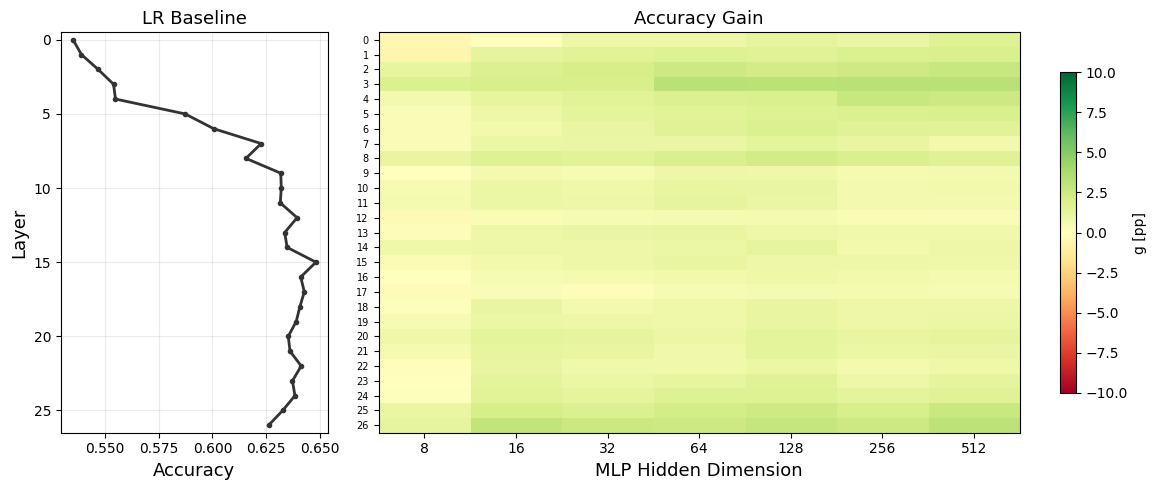

Qwen3-1_7B


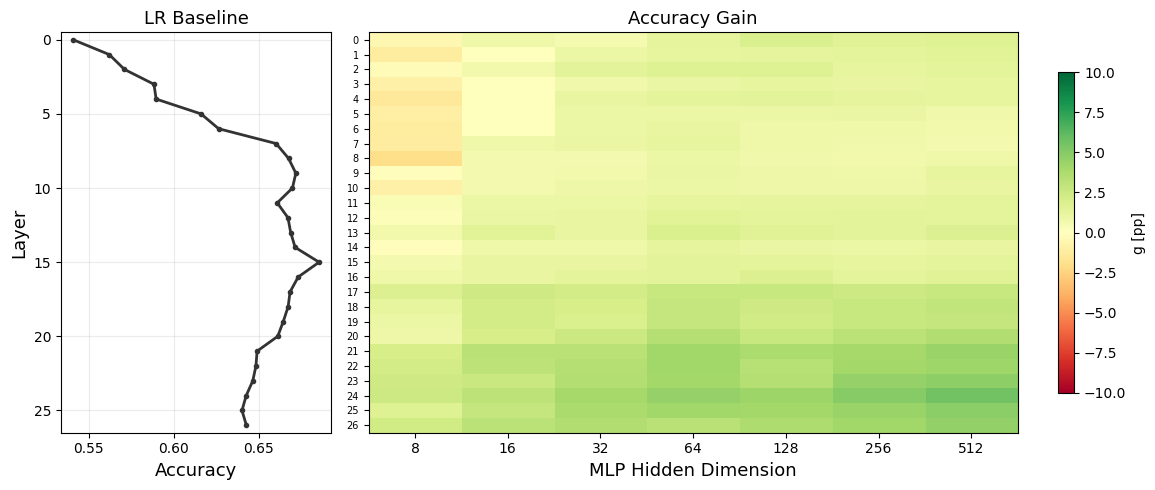

Qwen3-4B


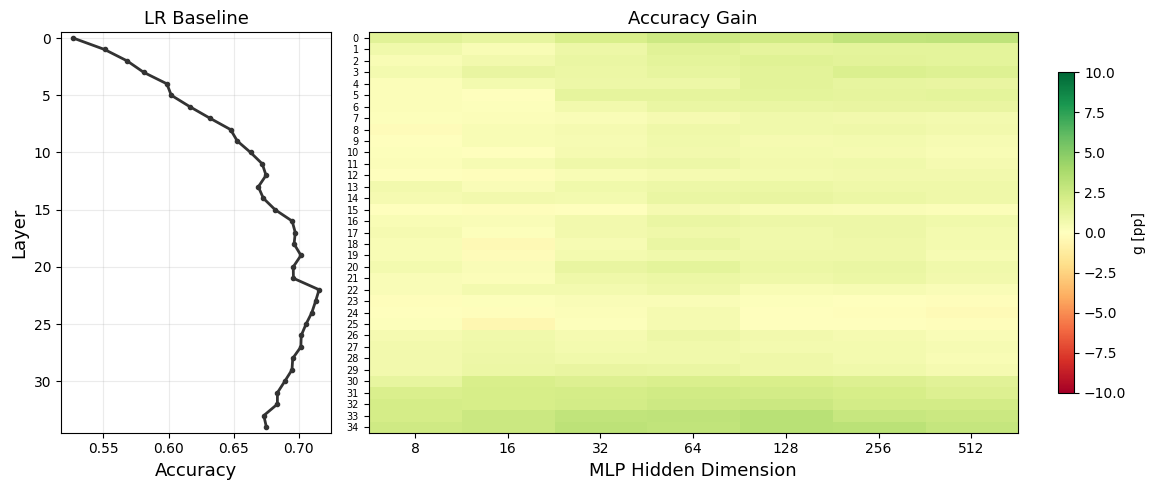

Qwen3-8B


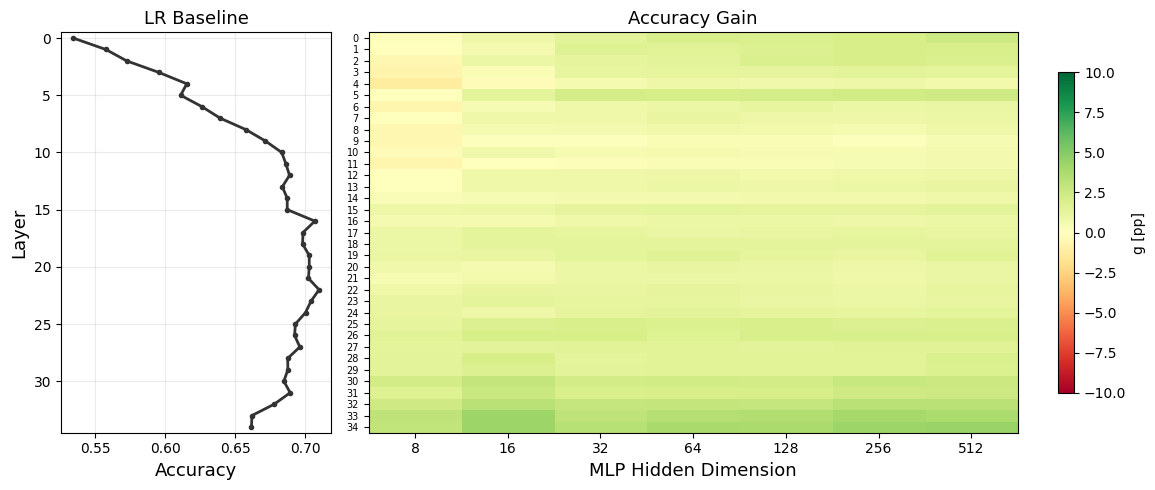

Qwen3-14B


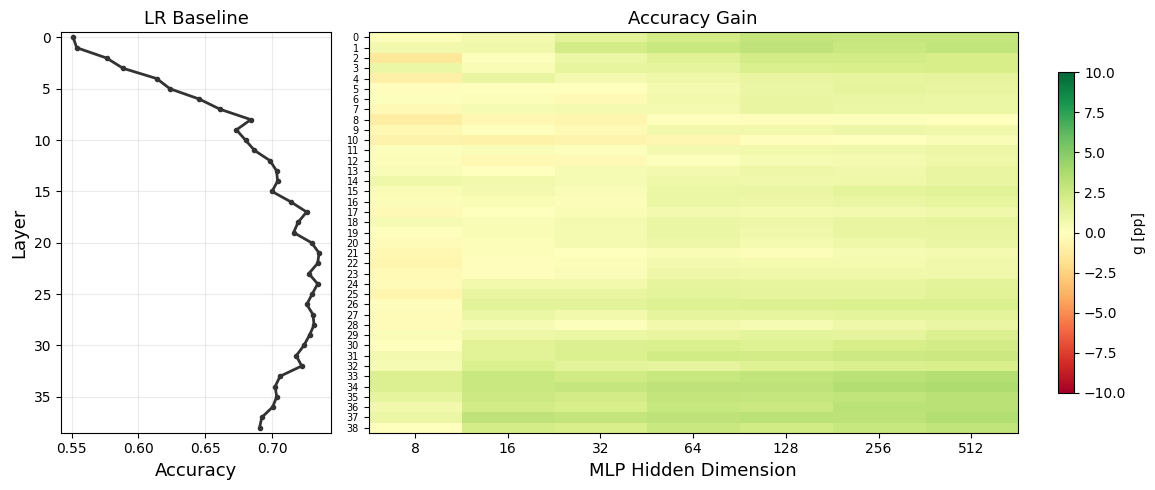

Qwen3-30B-A3B


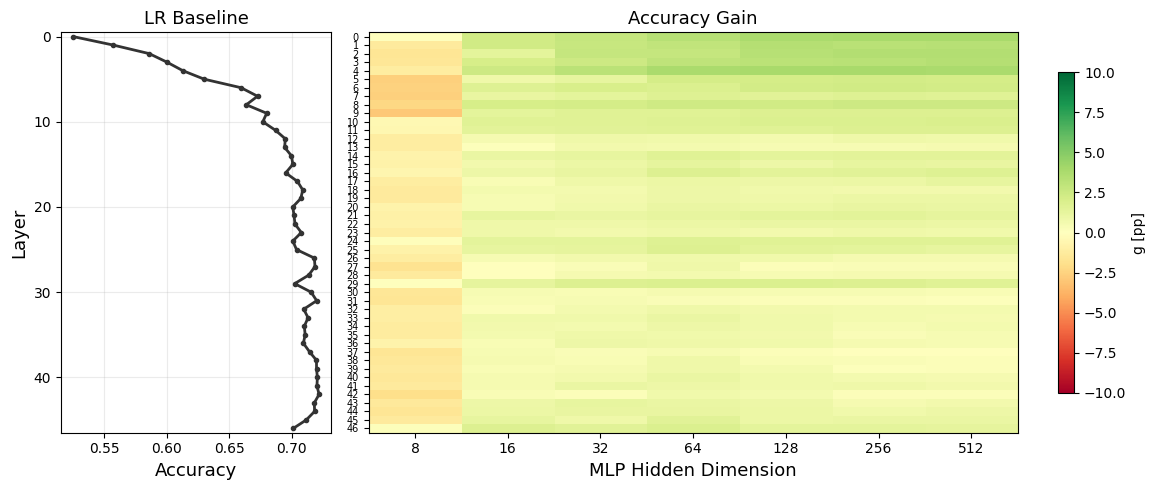

Qwen3-32B


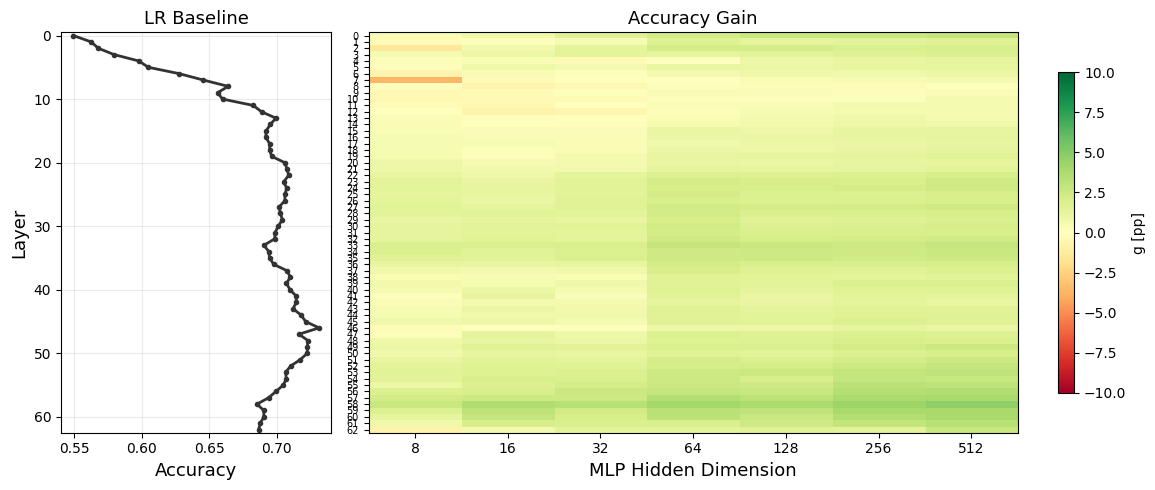

llama-3-1B


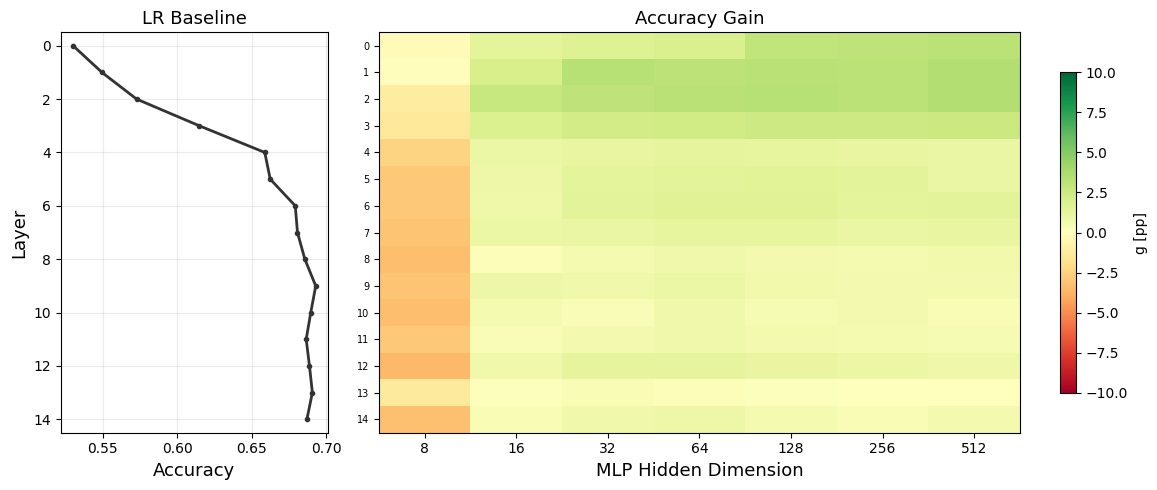

llama-3-3B


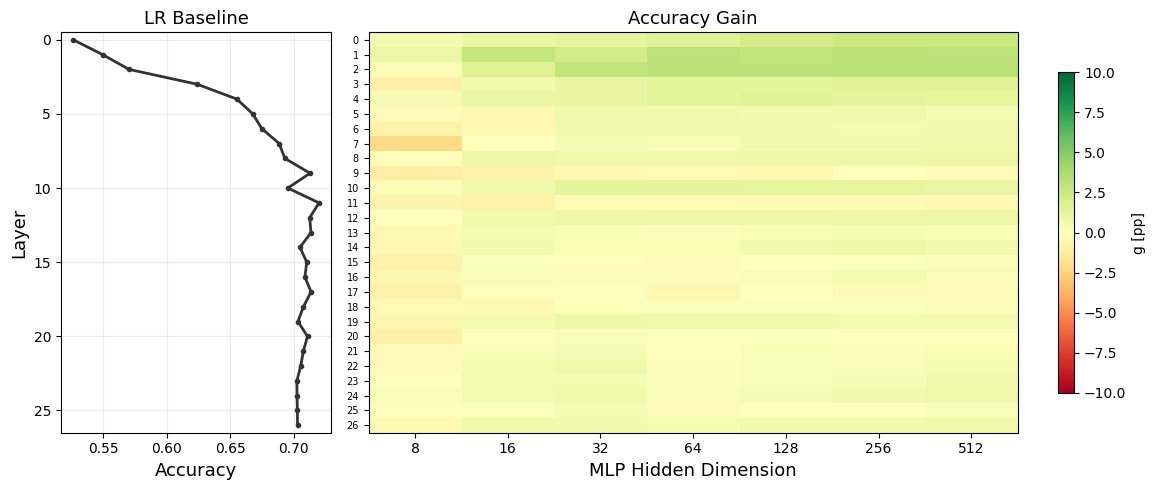

llama-3-8B


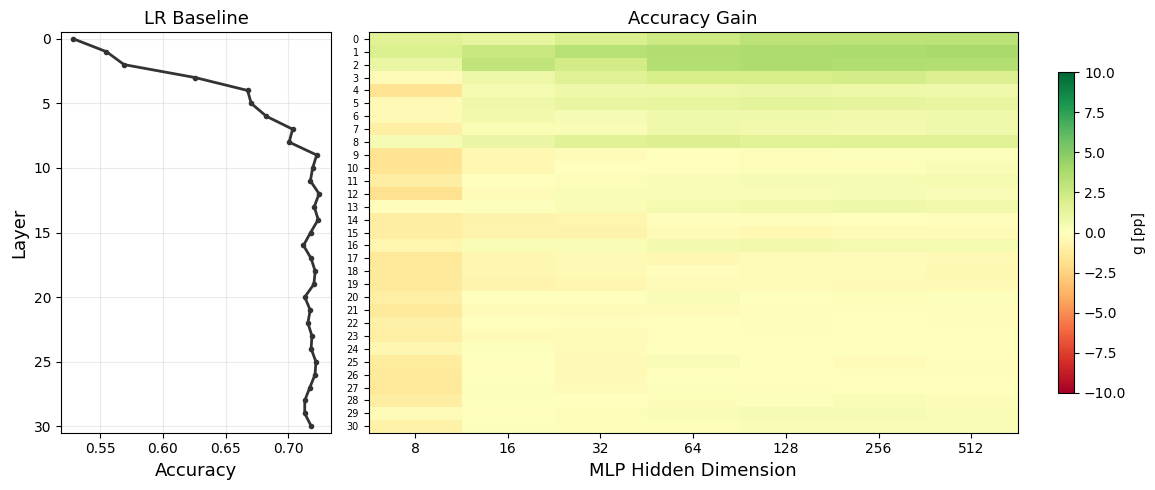

In [17]:
# +++ Per-model two-panel figure +++
# Left : LR accuracy across all layers (line plot)
# Right: (MLP_acc − LR_acc) heatmap

def plot_layerwise_heatmap(
    ldf: pd.DataFrame,
    model: str,
    hidden_dims: list = None,
    figsize=(12, 5),
    vmin_delta: float = -10,
    vmax_delta: float = +10,
    save_path: str = None):
    """
    Two-panel figure for one model.

    Parameters
    ----------
    ldf         : layerwise results DataFrame (from load_layerwise_results)
    model       : model name string
    hidden_dims : which MLP widths to include (default: all present in data)
    vmin_delta / vmax_delta : colormap range for the delta heatmap
    save_path   : if given, save figure to this path (PDF/PNG)
    """
    print(model)
    mdf = ldf[ldf["model"] == model].copy()
    #n_layers = get_layer(model, "d")#int(mdf["n_layers"].iloc[0])
    layers   = sorted(mdf["layer"].unique())
    # n_layers = layers[-1]
    # rel_dep  = [layer / (n_layers - 1) for layer in layers]
    # decile_layers   =[min(int(rel_dep_i * 10), 9) for rel_dep_i in rel_dep]

    if hidden_dims is None:
        hidden_dims = sorted(mdf[~mdf["is_linear"]]["hidden_dim"].unique())

    # Compute mean accuracy per (layer, probe_type, hidden_dim)
    # averaging over val_datasets and medleys
    lr_mean = (
        mdf[mdf["is_linear"] & (mdf["probe"] == "LRProbe")]
        .groupby("layer")["accuracy"].mean()
        .reindex(layers)
    )

    # delta matrix: rows=layers, cols=hidden_dim
    delta = np.full((len(layers), len(hidden_dims)), np.nan)
    for j, hd in enumerate(hidden_dims):
        mlp_mean = (
            mdf[mdf["hidden_dim"] == hd]
            .groupby("layer")["accuracy"].mean()
            .reindex(layers)
        )
        delta[:, j] = (mlp_mean - lr_mean).values * 100

    # Figure 
    fig, (ax_lr, ax_delta) = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [1, 3]},
    )

    # Left: LR accuracy line
    ax_lr.plot(lr_mean.values, layers, color="#333333", linewidth=2, marker="o",
               markersize=3)
    ax_lr.set_xlabel("Accuracy", fontsize=13)
    ax_lr.set_ylabel("Layer", fontsize=13)
    ax_lr.set_ylim(layers[0] - 0.5, layers[-1] + 0.5)
    ax_lr.invert_yaxis()       # layer 0 at top
    ax_lr.grid(True, alpha=0.25)
    ax_lr.set_title("LR Baseline", fontsize=13)

    # Right: delta heatmap
    im = ax_delta.imshow(
        delta,
        aspect="auto",
        cmap="RdYlGn",
        vmin=vmin_delta,
        vmax=vmax_delta,
        interpolation="nearest",
    )
    ax_delta.set_xlabel("MLP Hidden Dimension", fontsize=13)
    ax_delta.set_yticks(range(len(layers)))
    ax_delta.set_yticklabels(layers, fontsize=7)
    ax_delta.set_xticks(range(len(hidden_dims)))
    ax_delta.set_xticklabels(hidden_dims, fontsize=10)
    ax_delta.set_title("Accuracy Gain", fontsize=13)

    plt.colorbar(im, ax=ax_delta, label="g [pp]", shrink=0.8)
    plt.tight_layout()
    #if save_path:
    #  plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


# run:
ldf = load_layerwise_results(medleys=medleys, val_datasets=val_datasets)
for model in ALL_MODELS:
    plot_layerwise_heatmap(ldf, model, save_path=f"all_toxicity_results/Accuracy_gain_heatmap_{model}_software_toxicity.pdf")

In [18]:
# +++ Calculate NL_mean for all layers 

def compute_layerwise_nls(ldf: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the Non-Linearity Score at every individual layer.

    NLS(model, layer) = mean over hidden_dims of (MLP_acc − LR_acc),
                        further averaged over val_datasets and medleys.

    Returns a DataFrame with columns:
      model | family | layer | n_layers | rel_depth | decile |
      nls | max_gain | saturation_dim | lr_acc_mean
    """
    records = []
    for (model, layer), grp in ldf.groupby(["model", "layer"]):
        family   = grp["family"].iloc[0]
        n_layers = int(grp["n_layers"].iloc[0])
        rel_dep  = layer / (n_layers - 1)
        decile   = min(int(rel_dep * 10), 9)

        lr_acc = grp[grp["probe"] == "LRProbe"]["accuracy"].mean()
        if np.isnan(lr_acc):
            continue

        mlp_grp = grp[grp["hidden_dim"] > 0]
        if mlp_grp.empty:
            continue

        hd_means = (
            mlp_grp.groupby("hidden_dim")["accuracy"].mean()
            .sort_index()
        )
        gains      = (hd_means.values - lr_acc) * 100
        nls        = float(gains.mean())
        max_gain   = float(gains.max())

        # Saturation: first hidden_dim where gain >= 90 % of max_gain
        if max_gain > 0:
            sat_idx = int(np.argmax(gains >= 0.9 * max_gain))
        else:
            sat_idx = 0
        sat_dim = int(hd_means.index[sat_idx])

        records.append({
            "model":           model,
            "family":          family,
            "layer":           layer,
            "n_layers":        n_layers,
            "rel_depth":       rel_dep,
            "decile":          decile,
            "nls":             nls,
            "max_gain":        max_gain,
            "saturation_dim":  sat_dim,
            "lr_acc_mean":     float(lr_acc),
        })

    return pd.DataFrame(records)


nls_layer = compute_layerwise_nls(ldf)
nls_layer.groupby(["family","decile"])["nls"].mean().unstack()

decile,0,1,2,3,4,5,6,7,8,9
family,,,,,,,,,,
Llama-3,2.476878,1.130168,0.709681,0.217125,0.176152,0.046693,-0.138417,-0.055613,0.091547,0.113511
Qwen3,1.467404,0.790497,0.548669,0.839255,0.984667,1.046043,0.903900,1.072543,1.646533,2.371452


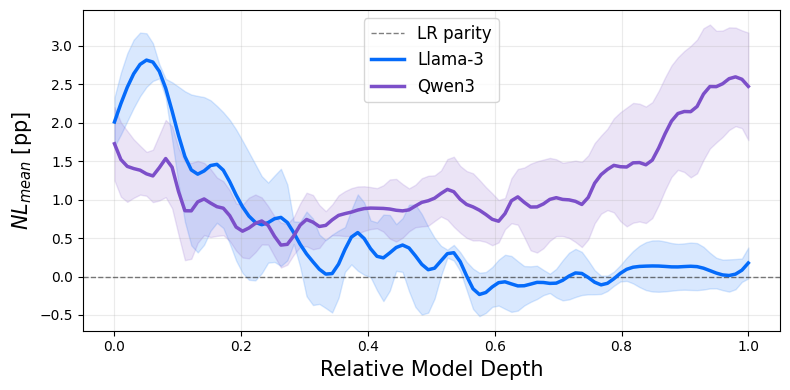

In [19]:
# +++ Plot NL_mean +++
# with ± 95% CI across models within each family.

def plot_nls_by_relative_depth(
    nls_layer: pd.DataFrame,
    families: list = None,
    n_interp: int = 100,
    figsize=(8, 4),
    save_path: str = None,
):
    """
    NL_mean-vs-relative-depth curves per family.

    Uses scipy cubic interpolation per model to a shared [0,1] grid,
    then plots mean ± 95% CI band across models in each family.
    """
    from scipy.interpolate import interp1d

    if families is None:
        families = sorted(nls_layer["family"].unique())

    family_colors = {
        "Qwen3":   "#7C4FC9",
        "Llama-3": "#056BFA",
    }

    xs = np.linspace(0, 1, n_interp)
    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5,
               label="LR parity")

    for family in families:
        fdf    = nls_layer[nls_layer["family"] == family]
        models = fdf["model"].unique()
        curves = []
        for model in models:
            mdf = fdf[fdf["model"] == model].sort_values("rel_depth")
            if len(mdf) < 3:
                continue
            # Cubic interpolation; uses linear at edges to avoid ringing
            f = interp1d(
                mdf["rel_depth"].values, mdf["nls"].values,
                kind="cubic", bounds_error=False, fill_value="extrapolate",
            )
            curves.append(f(xs))

        if not curves:
            continue

        arr  = np.array(curves) # shape (n_models, n_interp)
        mean = arr.mean(axis=0)
        sem  = arr.std(axis=0) / np.sqrt(len(arr))
        ci   = 1.96 * sem #2.326, 1.96

        color = family_colors.get(family, "#888888")
        ax.plot(xs, mean, color=color, linewidth=2.5, label=family)
        ax.fill_between(xs, mean - ci, mean + ci, color=color, alpha=0.15)

    ax.set_xlabel("Relative Model Depth", fontsize=15)
    ax.set_ylabel(r"$NL_{mean}$ [pp]", fontsize=15)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    #if save_path:
    #    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


plot_nls_by_relative_depth(nls_layer, save_path="all_toxicity_results/NL_mean_truthfulness.pdf")


---
## Probe Convergence Analysis

In [20]:
# ── T1: Build and melt training-info DataFrame ──────────────────────────────
#
# `make_training_info_statistics` (your existing function, reproduced here
# with minor fixes) produces one row per (model, layer) in WIDE format.
# `melt_training_info` converts it to LONG format — one row per
# (model, layer, probe_type) — which all downstream plots consume.
#
# probe_type values:  "LR"  |  "MLP_8" | "MLP_16" | ... | "MLP_512"
# key columns added:  hidden_dim (int, 0 for LR), is_linear (bool)

def make_training_info_statistics(ldf: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate training_info columns from the layer-wise results DataFrame.

    Expects ldf to contain columns: best_epoch, probe, hidden_dim
    (populated by load_results when training_info is stored in the JSON).

    Returns one row per (model, layer) with columns:
      lr_mean_epoch | lr_std_epoch |
      hd_<k>_mean_epoch | hd_<k>_std_epoch  for each hidden_dim k
    """
    records = []
    for (model, layer), grp in ldf.groupby(["model", "layer"]):
        family   = grp["family"].iloc[0]
        n_layers = int(grp["n_layers"].iloc[0])
        rel_dep  = layer / (n_layers - 1)
        decile   = min(int(rel_dep * 10), 9)

        lr_sub = grp[grp["probe"] == "LRProbe"]["best_epoch"]
        if lr_sub.empty or lr_sub.isna().all():
            continue
        lr_mean = lr_sub.mean()
        lr_std  = lr_sub.std()
        if np.isnan(lr_mean):
            continue

        mlp_grp = grp[grp["hidden_dim"] > 0]
        if mlp_grp.empty:
            continue

        mlp_means = {
            f"hd_{int(dim)}_mean_epoch": vals["best_epoch"].mean()
            for dim, vals in mlp_grp.groupby("hidden_dim")
        }
        mlp_stds = {
            f"hd_{int(dim)}_std_epoch": vals["best_epoch"].std()
            for dim, vals in mlp_grp.groupby("hidden_dim")
        }
        records.append({
            "model":         model,
            "family":        family,
            "layer":         layer,
            "n_layers":      n_layers,
            "rel_depth":     rel_dep,
            "decile":        decile,
            "lr_mean_epoch": float(lr_mean),
            "lr_std_epoch":  float(lr_std),
            **mlp_means,
            **mlp_stds,
        })
    return pd.DataFrame(records)


def melt_training_info(df_training: pd.DataFrame) -> pd.DataFrame:
    """
    Convert wide df_training to long form.

    Each row in the output represents one (model, layer, probe_type)
    with columns:
        model | family | layer | n_layers | rel_depth | decile |
        probe_type | hidden_dim | is_linear | mean_epoch | std_epoch

    probe_type examples: "LR", "MLP_8", "MLP_16", ..., "MLP_512"
    """
    hidden_dims = sorted(set(
        int(col.split("_")[1])
        for col in df_training.columns
        if col.startswith("hd_") and col.endswith("_mean_epoch")
    ))

    meta_cols = ["model", "family", "layer", "n_layers", "rel_depth", "decile"]
    records   = []

    for _, row in df_training.iterrows():
        base = {c: row[c] for c in meta_cols}

        # LR row
        records.append({
            **base,
            "probe_type": "LR",
            "hidden_dim": 0,
            "is_linear":  True,
            "mean_epoch": row["lr_mean_epoch"],
            "std_epoch":  row.get("lr_std_epoch", np.nan),
        })

        # MLP rows
        for hd in hidden_dims:
            mean_col = f"hd_{hd}_mean_epoch"
            std_col  = f"hd_{hd}_std_epoch"
            if mean_col not in row.index or np.isnan(row[mean_col]):
                continue
            records.append({
                **base,
                "probe_type": f"MLP_{hd}",
                "hidden_dim": hd,
                "is_linear":  False,
                "mean_epoch": float(row[mean_col]),
                "std_epoch":  float(row.get(std_col, np.nan)),
            })

    long_df = pd.DataFrame(records)
    # Ordered probe_type category for consistent x-axis ordering
    pt_order = ["LR"] + [f"MLP_{hd}" for hd in hidden_dims]
    long_df["probe_type"] = pd.Categorical(
        long_df["probe_type"], categories=pt_order, ordered=True
    )
    return long_df


# Usage:
df_training = make_training_info_statistics(ldf)
long_df     = melt_training_info(df_training)
print(long_df[["model","layer","probe_type","hidden_dim","mean_epoch"]].head(10))

        model  layer probe_type  hidden_dim  mean_epoch
0  Qwen3-0_6B      0         LR           0      73.500
1  Qwen3-0_6B      0      MLP_8           8      44.375
2  Qwen3-0_6B      0     MLP_16          16      38.875
3  Qwen3-0_6B      0     MLP_32          32      38.375
4  Qwen3-0_6B      0     MLP_64          64      37.375
5  Qwen3-0_6B      0    MLP_128         128      38.750
6  Qwen3-0_6B      0    MLP_256         256      39.500
7  Qwen3-0_6B      0    MLP_512         512      26.375
8  Qwen3-0_6B      1         LR           0      44.500
9  Qwen3-0_6B      1      MLP_8           8      53.875


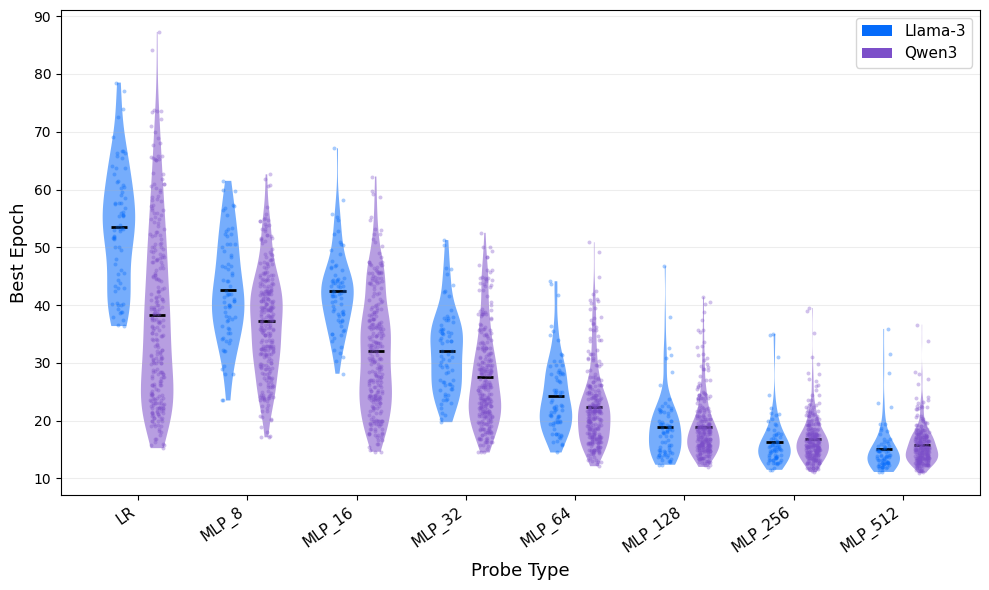

In [21]:
# ── T2: Violin plot — best_epoch distribution per probe type ────────────────
#
# Each violin shows the distribution of mean_epoch values across all
# (model, layer) combinations for that probe type.  Splitting by family
# reveals whether convergence patterns differ architecturally.
#
# Reading guide:
#   Wide violin  → high variance in when this probe type converges
#   Median line  → typical convergence point
#   Long upper tail → some layers take much longer (hard-to-probe layers)

def plot_epoch_distributions(
    long_df: pd.DataFrame,
    figsize=(10, 6),
    save_path: str = None,
):
    """
    Split violins per probe_type, coloured by family.

    The box inside each violin marks Q1–Q3; the white dot marks the median.
    Overlaid strip (jittered dots) shows individual (model, layer) data points
    so you can see the raw scatter, not just the KDE.
    """
    families = sorted(long_df["family"].unique())
    family_colors = {
        "Qwen3":   "#7C4FC9",#"#615CED",#"#E07B39", 915CED, #7C4FC9, #633FA1
        "Llama-3": "#056BFA",#"#4477AA", 0457CB
        "Gemma3":  "#228833",
        "Qwen3-VL":"#AA3377",
    }
    probe_order = long_df["probe_type"].cat.categories.tolist()
    x_pos       = {pt: i for i, pt in enumerate(probe_order)}
    n_fam       = len(families)
    width       = 0.35
    offsets     = np.linspace(-width*(n_fam-1)/2, width*(n_fam-1)/2, n_fam)

    fig, ax = plt.subplots(figsize=figsize)

    for fam, offset in zip(families, offsets):
        color = family_colors.get(fam, "#888888")
        fdf   = long_df[long_df["family"] == fam]

        positions = [x_pos[pt] + offset for pt in probe_order]
        data      = [fdf[fdf["probe_type"] == pt]["mean_epoch"].dropna().values
                     for pt in probe_order]

        parts = ax.violinplot(
            data, positions=positions,
            widths=width * 0.85,
            showmeans=True, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.55)
        parts["cmeans"].set_color("black")
        parts["cmeans"].set_linewidth(2)

        # Strip: jittered raw points
        rng = np.random.default_rng(42)
        for pt, pos, d in zip(probe_order, positions, data):
            if len(d) == 0:
                continue
            jitter = rng.uniform(-width*0.18, width*0.18, len(d))
            ax.scatter(pos + jitter, d, color=color, s=8,
                       alpha=0.35, zorder=3, linewidths=0)

    # Legend
    handles = [plt.matplotlib.patches.Patch(
                   facecolor=family_colors.get(f, "#888"), label=f)
               for f in families]
    ax.legend(handles=handles, fontsize=11, frameon=True)

    ax.set_xticks(range(len(probe_order)))
    ax.set_xticklabels(probe_order, rotation=35, ha="right", fontsize=11)
    ax.set_ylabel("Best Epoch", fontsize=13)
    ax.set_xlabel("Probe Type", fontsize=13)
    #ax.set_title(
    #    "Distribution of best_epoch across all (model, layer) combinations \n Violin = KDE;  box = IQR;  dots = individual observations",
    #    fontsize=11,
    #)
    ax.grid(True, axis="y", alpha=0.22)
    plt.tight_layout()
    if save_path:
       plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


long_df = melt_training_info(df_training)
plot_epoch_distributions(long_df, save_path="all_toxicity_results/epoch_distributions_toxicity.pdf")


---
## Consistency of Toxic Representations

In [ ]:
# +++ Scorer Definition +++

# ── Change this one line to swap scorers everywhere ──────────────────────────
ACTIVE_SCORER = "S1"   # "S0" | "S1"

import warnings

def _G(deltas: np.ndarray) -> float:
    """Asymptotic gain: maximum observed delta across all capacity levels."""
    
    return float(np.max(deltas))

# S0: NL_mean
def scorer_S0(deltas: np.ndarray, lr_acc: float) -> dict:
    """
    NL_mean comparision
    """

    return {"score": deltas.mean(), "G": deltas.mean(), "std": deltas.std()}

def scorer_S1(deltas: np.ndarray, lr_acc: float) -> dict:
    """
    S3 = G · C    where    C = (1/K) Σ_k clip(Δ(h_k) / G, 0, 1)

    Range: [0, G]    (= G when C = 1, G = 0 when C = 0)
    """
    deltas  = deltas * 100
    G = _G(deltas)
    if G < 1e-9:
        C = 0.0
        score     = 0.0
    else:
        normalised = np.clip(deltas / G, 0.0, 1.0)
        C  = float(normalised.mean())
        score      = G * C

    return {"score": score, "G": G, "rho_tilde": C} # We initially called C rho_tilde during dev

# Scorer Registry
SCORERS = {
    "S0": scorer_S0,
    "S1": scorer_S1,
}

SCORER_LABELS = {
    "S0": r"NL_{mean}",
    "S1": r"$NL_{C} = G \cdot C$"
}

print(f"Active scorer: {ACTIVE_SCORER}  —  {SCORER_LABELS[ACTIVE_SCORER]}")
print(f"Available scorers: {list(SCORERS.keys())}")

Active scorer: S1  —  $NL_{C} = G \cdot C$
Available scorers: ['S0', 'S1']


In [25]:
# +++ Compute Scores +++
# Returns one row per (model, <layer_col>) with scores from the active scorer
# plus supplementary columns G, and scorer-specific extras (rho_tilde, etc.).

def compute_scores(
    df: pd.DataFrame,
    scorer_name: str = None,
    groupby: list = None,
) -> pd.DataFrame:
    """
    Compute the active (or specified) non-linearity score for every
    (model, layer) combination.

    Parameters
    ----------
    df          : results DataFrame with columns model, family, hidden_dim,
                  probe, accuracy, and a layer column.
    scorer_name : one of "S0", "S1" (default: ACTIVE_SCORER).
    groupby     : grouping columns. Default: ["model","family","layer"]

    Returns
    -------
    DataFrame with one row per group.  Always contains:
      model | family | <layer_col> | score | G | scorer
    Plus scorer-specific extras (rho_tilde for S3; headroom for S1; etc.)
    Also always includes:
      lr_acc       : mean LR accuracy at that (model, layer)
      G_raw_mean   : old mean-delta NLS (kept for backward comparison)
      n_hd         : number of hidden-dim levels used
      saturation_dim : smallest h achieving ≥ 90% of G  (or NaN)
    """
    if scorer_name is None:
        scorer_name = ACTIVE_SCORER
    scorer_fn = SCORERS[scorer_name]

    if groupby is None:
        groupby = ["model", "family", "layer"]

    # Compute mean accuracy per hidden_dim, averaged over
    # val_datasets and medleys
    mlp_df = df[df["hidden_dim"] > 0].copy()
    lr_df  = df[df["probe"] == "LRProbe"].copy()

    records = []
    for keys, grp in mlp_df.groupby(groupby):
        key_dict = dict(zip(groupby, keys if isinstance(keys, tuple) else [keys]))

        hd_means = (
            grp.groupby("hidden_dim")["accuracy"]
            .mean()
            .sort_index()
        )
        hidden_dims = hd_means.index.values.astype(float)
        deltas_raw  = hd_means.values  # absolute acc, not yet delta

        # LR baseline
        lr_mask = np.ones(len(lr_df), dtype=bool)
        for col, val in key_dict.items():
            if col in lr_df.columns:
                lr_mask &= (lr_df[col] == val)
        lr_sub  = lr_df[lr_mask]["accuracy"]
        if lr_sub.empty:
            continue
        lr_acc  = float(lr_sub.mean())

        deltas = deltas_raw - lr_acc   # Δ(h_k) = acc_MLP(h_k) - acc_LR

        # Run scorer
        result = scorer_fn(deltas, lr_acc)

        G_raw_mean = float(deltas.mean())

        # Saturation dim: smallest h_k where Δ(h_k) ≥ 0.9 * G
        G = result["G"]
        threshold = 0.9 * G
        sat_candidates = np.where(deltas >= threshold)[0]
        sat_dim = int(hidden_dims[sat_candidates[0]]) if len(sat_candidates) else int(hidden_dims[-1])

        records.append({
            **key_dict,
            "score":        result["score"],
            "G":            G,
            "lr_acc":       lr_acc,
            "G_raw_mean":   G_raw_mean,
            "n_hd":         len(hidden_dims),
            "hd_min":       int(hidden_dims[0]),
            "hd_max":       int(hidden_dims[-1]),
            "saturation_dim": sat_dim,
            "scorer":       scorer_name,
            # Pass through all scorer-specific extras
            **{k: v for k, v in result.items() if k not in ("score", "G")},
        })

    out = pd.DataFrame(records)

    # Attach relative depth if layer column is absolute
    layer_col = [c for c in groupby if c not in ("model", "family")][0]
    if layer_col == "layer" and "n_layers" in df.columns:
        n_layers_map = df.groupby("model")["n_layers"].first()
        out["n_layers"]  = out["model"].map(n_layers_map)
        out["rel_depth"] = out["layer"] / (out["n_layers"] - 1)
        out["decile"]    = (out["rel_depth"] * 10).clip(upper=9.999).astype(int)

    return out


# Convenience wrapper
def compute_all_scorers(df: pd.DataFrame, groupby: list = None) -> pd.DataFrame:
    """Run S0 and S1 and return a single DataFrame with a 'scorer' column."""
    return pd.concat(
        [compute_scores(df, scorer_name=s, groupby=groupby) for s in SCORERS],
        ignore_index=True,
    )


scores = compute_scores(ldf)                    # uses ACTIVE_SCORER
all_s  = compute_all_scorers(ldf)              # all three stacked


In [24]:
# +++ Sanity checks +++

def _check_all_scorers(label, deltas, lr_acc=0.60):
    print(f"\n  {label}:  Δ = {np.round(deltas, 3).tolist()}")
    for name, fn in SCORERS.items():
        out = fn(deltas, lr_acc)
        print(f"    {name}: " + "  ".join(f"{k}={v:.4f}" for k, v in out.items()))

K   = 7
c   = 0.04
LR  = 0.70

deltas_A = np.full(K, c)                              # uniform gain
deltas_B = np.array([0.]*6 + [K * c])                # gain only at h_max
deltas_C = np.linspace(0, c, K)                      # linear rise
deltas_D = np.array([-0.01, -0.005, 0., 0.01, 0.02, 0.03, c])  # starts negative
deltas_E = np.array([-0.08, -0.05, -0.01, -0.01, -0.02, -0.03, -c])  # starts negative, stays negative
deltas_F = np.array([-0.08, -0.05, -0.01, 0.01, 0.025, 0.01, 0.005]) 

print("=" * 60)
print("Sanity checks — LR acc =", LR)
_check_all_scorers("Layer A (uniform gain)", deltas_A, LR)
_check_all_scorers("Layer B (gain only at h_max)", deltas_B, LR)
_check_all_scorers("Layer C (linear rise 0→c)", deltas_C, LR)
_check_all_scorers("Layer D (starts negative, rises to c)", deltas_D, LR)
_check_all_scorers("Layer E (starts negative, stays negative)", deltas_E, LR)
_check_all_scorers("Layer F (starts negative, rises and reaches peak at k=5)", deltas_F, LR)
print()


Sanity checks — LR acc = 0.7

  Layer A (uniform gain):  Δ = [0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04]
    S0: score=0.0400  G=0.0400  std=0.0000
    S1: score=4.0000  G=4.0000  rho_tilde=1.0000

  Layer B (gain only at h_max):  Δ = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.28]
    S0: score=0.0400  G=0.0400  std=0.0980
    S1: score=4.0000  G=28.0000  rho_tilde=0.1429

  Layer C (linear rise 0→c):  Δ = [0.0, 0.007, 0.013, 0.02, 0.027, 0.033, 0.04]
    S0: score=0.0200  G=0.0200  std=0.0133
    S1: score=2.0000  G=4.0000  rho_tilde=0.5000

  Layer D (starts negative, rises to c):  Δ = [-0.01, -0.005, 0.0, 0.01, 0.02, 0.03, 0.04]
    S0: score=0.0121  G=0.0121  std=0.0173
    S1: score=1.4286  G=4.0000  rho_tilde=0.3571

  Layer E (starts negative, stays negative):  Δ = [-0.08, -0.05, -0.01, -0.01, -0.02, -0.03, -0.04]
    S0: score=-0.0343  G=-0.0343  std=0.0232
    S1: score=0.0000  G=-1.0000  rho_tilde=0.0000

  Layer F (starts negative, rises and reaches peak at k=5):  Δ = [-0.08, -0.05, -0

/var/folders/l_/qy6xpxn531ngvxwsvs64x62h0000gn/T/ipykernel_1739/3027834038.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, ncol=2, loc="best", frameon=False)


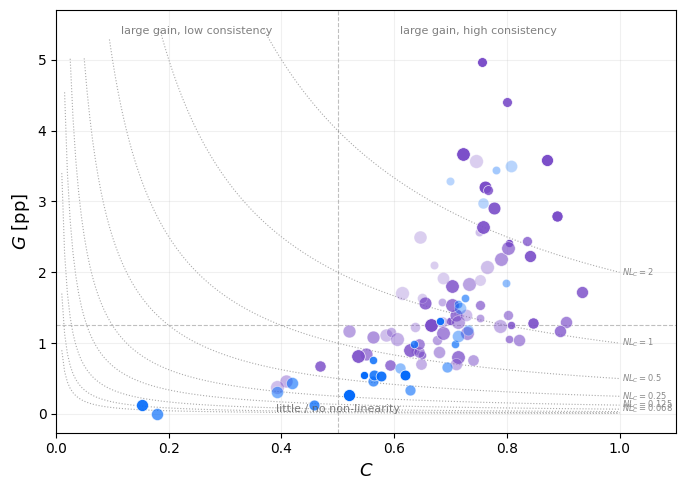

In [26]:
# +++ (G, C) two-dimensional characterisation scatter +++

def plot_G_rho_scatter(
    df: pd.DataFrame,
    groupby_layer: str = "decile",
    min_G: float = 0.0,
    show_contours: bool = True,
    figsize=(7, 5),
    save_path: str = None,
):
    """
    Two-dimensional (G, C) scatter

    Parameters
    ----------
    min_G           : filter out points with G < min_G (reduces clutter)
    show_contours   : overlay NL_C = G·C iso-curves
    """
    scores = compute_scores(df, scorer_name="S1",
                            groupby=["model", "family", groupby_layer])
    if "rho_tilde" not in scores.columns:
        raise ValueError("rho_tilde column missing — ensure scorer_name='S1'")

    scores = scores[scores["G"] >= min_G].copy()
    #print(scores)
    family_colors  = {
        "Qwen3":   "#7C4FC9",
        "Llama-3": "#056BFA",
    }

    model_sizes = {
        "Qwen3-0_6B": 35,
        "llama-3-1B": 35,
        "Qwen2-1_5B": 50,
        "Qwen2_5-1_5B": 50,
        "Qwen1_5-1_8B": 50,
        "Qwen3-1_7B": 50,
        "llama-3-3B": 60,
        "Qwen3-4B": 65,
        "Qwen3-8B": 75,
        "llama-3-8B": 75,
        "Qwen3-14B": 85,
        "Qwen3-30B-A3B": 95,
        "Qwen3-32B": 95,
    }

    fig, ax = plt.subplots(figsize=figsize)

    # iso-contours 
    if show_contours:
        rho_grid = np.linspace(0.01, 1.0, 200)
        contour_levels = [0.009, 0.017, 0.034, 0.068, 0.125, 0.25, 0.5, 1, 2]#, 0.08, 0.16] #0.009, 0.017, 0.034, 0.068,
        for i, S_val in enumerate(contour_levels):
            G_grid = S_val / rho_grid
            mask   = (G_grid >= 0) & (G_grid <= scores["G"].max() * 1.1)
            ax.plot(rho_grid[mask], G_grid[mask],
                    color="#AAAAAA", linewidth=0.8, linestyle=":",
                    zorder=1)
            # Label contour at right edge

            rho_label = rho_grid[mask][-1]
            G_label   = G_grid[mask][-1]
            if i <= 2:
                ax.text(rho_label + 0.005, G_label,
                        f"",
                        fontsize=6, color="#888888", va="center")
            else:             
                ax.text(rho_label + 0.005, G_label,
                        rf"$NL_C = ${S_val}",
                        fontsize=6, color="#888888", va="center")

    # Scatter 
    grouped = scores.groupby(["model", "family", groupby_layer]) if groupby_layer in scores.columns else scores.groupby("model")
    for keys, grp in grouped:
        if isinstance(keys, tuple):
            model, family, group = keys
        else:
            model, family, group = keys, None, None
        color  = family_colors.get(family, "#888888")
        alpha  = 0.2 + (0.8 * (grp["decile"] + 1) / 10.0)
        edgecolors = "white"
        ax.scatter(
            grp["rho_tilde"], grp["G"],
            c=color, marker="o", s=model_sizes.get(model, 65),
            alpha=alpha, edgecolors=edgecolors, linewidths=0.5,
            zorder=3,
        )

    # Quadrant shading
    G_mid   = scores["G"].quantile(0.5)
    rho_mid = 0.5
    alpha_q = 0.04
    ax.axvline(rho_mid, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axhline(G_mid,   color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    kw   = dict(fontsize=8, color="#555555", alpha=0.75)
    ax.text(rho_mid * 0.5,  ylim[1] * 0.96,
            "large gain, low consistency", ha="center", va="top", **kw)
    ax.text(rho_mid * 1.5,  ylim[1] * 0.96, "large gain, high consistency", ha="center", va="top", **kw)
    ax.text(0.5, ylim[0] * 1.02 if ylim[0] > 0 else abs(ylim[0]) * 0.02,
            "little / no non-linearity", ha="center", va="bottom", **kw)

    ax.set_xlabel(r"$C$", fontsize=13)
    ax.set_ylabel(r"$G$ [pp]", fontsize=13)
    ax.legend(fontsize=8, ncol=2, loc="best", frameon=False)
    ax.set_xlim(0, 1.1)
    #ax.set_ylim(-0.005, 0.035)
    ax.grid(True, alpha=0.18)

    plt.tight_layout()
    #if save_path:
    #  plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

plot_G_rho_scatter(ldf, save_path="all_toxicity_results/Iso_NL_clip_truthfulness.pdf")
